# Customer Segmentation & Cohort Analysis
### RFM-Based Customer Value Tiering for Retail E-commerce

---

| | |
|---|---|
| **Dataset** | UCI Online Retail II |
| **Source** | https://archive.ics.uci.edu/dataset/502/online+retail+ii |
| **Tools** | Python, pandas, NumPy, scikit-learn, Matplotlib, Seaborn, SQL (PostgreSQL) |
| **Techniques** | RFM Segmentation, K-Means Clustering, Cohort Retention Analysis |
| **Role Target** | Data Analyst |


---
## 1. Problem Statement

Retail businesses typically lose 20–30% of their customer base annually. Despite this, most marketing budgets treat all customers identically — spending the same acquisition and retention cost on a one-time buyer as on a high-value repeat customer.

**Business Question:** Can we segment customers by purchasing behaviour to identify who deserves retention investment, who is at risk of churning, and who has already lapsed — so marketing spend can be allocated accordingly?

**Approach:** Apply RFM (Recency, Frequency, Monetary) segmentation and monthly cohort retention analysis to ~500,000 UK retail transactions, producing four actionable customer tiers with tailored retention strategies per tier.


---
## 2. Dataset

**UCI Online Retail II** is a publicly available transactional dataset from a UK-based online retailer selling gift and homeware items.

| Property | Detail |
|---|---|
| Records | ~1,000,000 rows (two-year period) |
| Period | December 2009 – December 2011 |
| Customers | ~5,900 unique UK customers (after cleaning) |
| Key fields | Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country |

**Download instructions:**
1. Visit: https://archive.ics.uci.edu/dataset/502/online+retail+ii
2. Download `online_retail_II.xlsx`
3. Place it in the same folder as this notebook


---
## 3. Setup & Data Loading


In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Colour palette (consistent across all charts) ─────────────────────────
PALETTE = {
    'Champions': '#1F4E79',
    'Loyal':     '#2E75B6',
    'At-Risk':   '#F4A300',
    'Dormant':   '#C0392B'
}
SEGMENT_ORDER = ['Champions', 'Loyal', 'At-Risk', 'Dormant']
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:
# ── Load dataset ─────────────────────────────────────────────────────────
# Uses Year 2010-2011 sheet; adjust sheet_name if using 2009-2010
df_raw = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

print(f'Raw shape : {df_raw.shape}')
print(f'Columns   : {list(df_raw.columns)}')
df_raw.head()

Raw shape : (541910, 8)
Columns   : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


---
## 4. Exploratory Data Analysis


In [ ]:
# Missing value summary
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing values per column:')
print(summary[summary['Missing Count'] > 0])

print(f'\nDate range : {df_raw["InvoiceDate"].min()} → {df_raw["InvoiceDate"].max()}')
print(f'Countries  : {df_raw["Country"].nunique()}')
print(f'Customers  : {df_raw["Customer ID"].nunique():,}')

Missing values per column:
             Missing Count  Missing %
Description           1454       0.27
Customer ID         135080      24.93

Date range : 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Countries  : 38
Customers  : 4,372


In [ ]:
# Quantity and Price distributions
print('Quantity stats:')
print(df_raw['Quantity'].describe().round(2))
print('\nPrice stats:')
print(df_raw['Price'].describe().round(2))

print(f'\nCancelled orders (Invoice starts with C): '
      f'{df_raw["Invoice"].astype(str).str.startswith("C").sum():,}')

Quantity stats:
count   541910.00
mean         9.55
std        218.08
min     -80995.00
25%          1.00
50%          3.00
75%         10.00
max      80995.00
Name: Quantity, dtype: float64

Price stats:
count   541910.00
mean         4.61
std         96.76
min     -11062.06
25%          1.25
50%          2.08
75%          4.13
max      38970.00
Name: Price, dtype: float64

Cancelled orders (Invoice starts with C): 9,288


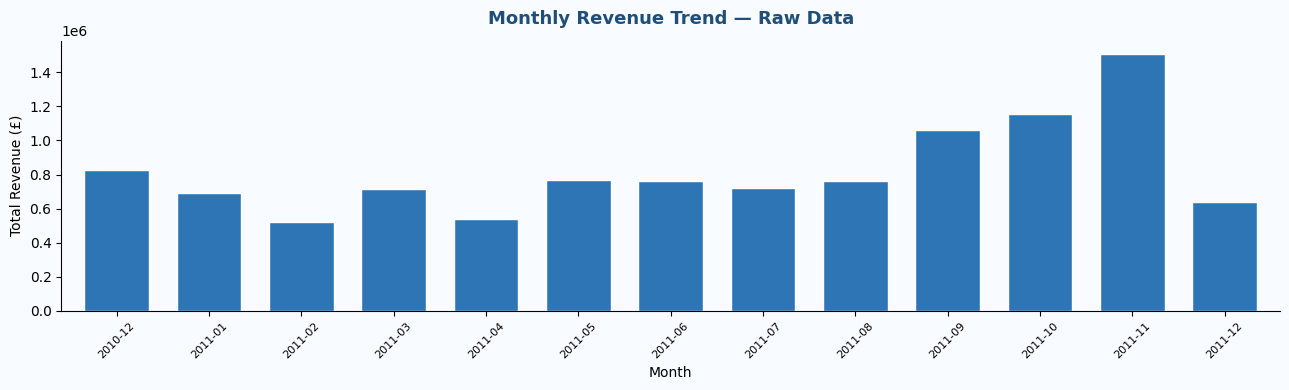

In [ ]:
# Monthly revenue trend (raw data)
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
df_raw['Revenue'] = df_raw['Quantity'] * df_raw['Price']
monthly = df_raw[df_raw['Revenue'] > 0].groupby(
    df_raw['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()

fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor('#F8FBFF')
ax.set_facecolor('#F8FBFF')
monthly.plot(kind='bar', ax=ax, color='#2E75B6', edgecolor='white', width=0.7)
ax.set_title('Monthly Revenue Trend — Raw Data', fontsize=13, fontweight='bold',
             color='#1F4E79', pad=12)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Total Revenue (£)', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 5. Data Cleaning


In [ ]:
df = df_raw.copy()

print('--- Cleaning Steps ---')

# Step 1: Remove cancelled orders
mask_cancel = df['Invoice'].astype(str).str.startswith('C')
df = df[~mask_cancel]
print(f'After removing cancellations : {len(df):,} rows')

# Step 2: Remove missing Customer IDs
df = df[df['Customer ID'].notna()]
print(f'After removing null CustomerID: {len(df):,} rows')

# Step 3: Remove non-positive Quantity and Price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f'After removing invalid Qty/Price: {len(df):,} rows')

# Step 4: UK customers only
df = df[df['Country'] == 'United Kingdom']
print(f'After UK filter              : {len(df):,} rows')

# Step 5: Recompute line revenue
df['Revenue'] = df['Quantity'] * df['Price']

print(f'\nFinal: {len(df):,} transactions | {df["Customer ID"].nunique():,} unique customers')

--- Cleaning Steps ---
After removing cancellations : 532,622 rows
After removing null CustomerID: 397,925 rows
After removing invalid Qty/Price: 397,885 rows
After UK filter              : 354,321 rows

Final: 354,321 transactions | 3,920 unique customers


---
## 6. RFM Metric Computation

RFM summarises each customer on three behavioural dimensions:

- **Recency (R):** Days since their most recent purchase — lower = more engaged
- **Frequency (F):** Number of distinct orders placed — higher = more loyal
- **Monetary (M):** Total spend across all orders — higher = more valuable


In [ ]:
# Snapshot date: day after last transaction in dataset
SNAPSHOT_DATE = pd.Timestamp('2011-12-10')

rfm = (
    df.groupby('Customer ID')
    .agg(
        last_purchase  = ('InvoiceDate', 'max'),
        frequency      = ('Invoice',     'nunique'),
        monetary_value = ('Revenue',     'sum')
    )
    .reset_index()
    .rename(columns={'Customer ID': 'customer_id'})
)

rfm['recency_days']    = (SNAPSHOT_DATE - rfm['last_purchase']).dt.days
rfm['monetary_value']  = rfm['monetary_value'].round(2)
rfm = rfm.drop(columns=['last_purchase'])

print(f'RFM table: {rfm.shape[0]:,} customers')
rfm.describe().round(2)

RFM table: 3,920 customers


,customer_id,frequency,monetary_value,recency_days
count,3920.00,3920.00,3920.00,3920.00
mean,15562.06,4.25,1864.39,91.74
std,1576.59,7.20,7482.82,99.53
min,12346.00,1.00,3.75,0.00
25%,14208.75,1.00,300.28,17.00
50%,15569.50,2.00,652.28,50.00
75%,16913.25,5.00,1576.58,142.00
max,18287.00,209.00,259657.30,373.00


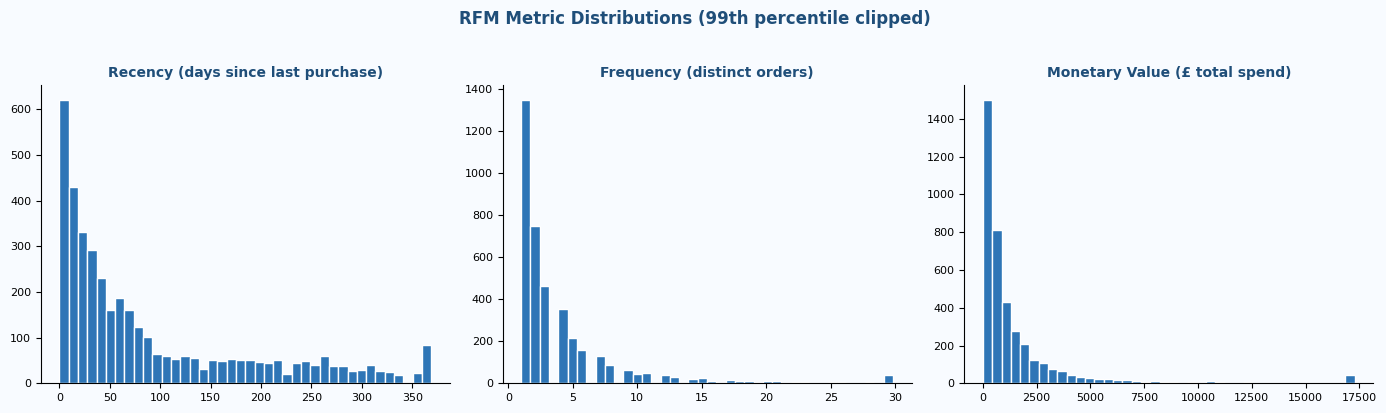

Note: All three metrics are right-skewed — typical for retail data.
A small number of high-value customers drive a disproportionate share of revenue.


In [ ]:
# Distribution of each RFM metric
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor('#F8FBFF')
metrics = ['recency_days', 'frequency', 'monetary_value']
titles  = ['Recency (days since last purchase)',
            'Frequency (distinct orders)',
            'Monetary Value (£ total spend)']

for ax, col, title in zip(axes, metrics, titles):
    ax.set_facecolor('#F8FBFF')
    ax.hist(rfm[col].clip(upper=rfm[col].quantile(0.99)),
            bins=40, color='#2E75B6', edgecolor='white')
    ax.set_title(title, fontsize=10, fontweight='bold', color='#1F4E79')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

fig.suptitle('RFM Metric Distributions (99th percentile clipped)',
             fontsize=12, fontweight='bold', color='#1F4E79', y=1.02)
plt.tight_layout()
plt.show()

print('Note: All three metrics are right-skewed — typical for retail data.')
print('A small number of high-value customers drive a disproportionate share of revenue.')

---
## 7. RFM Scoring (Quantile Binning)

Each metric is divided into 4 quartiles, scored 1 (worst) to 4 (best).
Recency is scored in reverse — a lower number of days means a higher score.


In [ ]:
rfm_s = rfm.copy()

# R score: lower recency_days = better → reversed labels
rfm_s['R_score'] = pd.qcut(
    rfm_s['recency_days'], q=4,
    labels=[4, 3, 2, 1], duplicates='drop'
).astype(int)

# F score: higher frequency = better
rfm_s['F_score'] = pd.qcut(
    rfm_s['frequency'].rank(method='first'), q=4,
    labels=[1, 2, 3, 4], duplicates='drop'
).astype(int)

# M score: higher monetary = better
rfm_s['M_score'] = pd.qcut(
    rfm_s['monetary_value'], q=4,
    labels=[1, 2, 3, 4], duplicates='drop'
).astype(int)

rfm_s['RFM_code']  = (rfm_s['R_score'].astype(str)
                      + rfm_s['F_score'].astype(str)
                      + rfm_s['M_score'].astype(str))
rfm_s['RFM_total'] = rfm_s['R_score'] + rfm_s['F_score'] + rfm_s['M_score']

# Assign segment labels
def assign_segment(score):
    if score >= 10: return 'Champions'
    elif score >= 7: return 'Loyal'
    elif score >= 4: return 'At-Risk'
    else: return 'Dormant'

rfm_s['segment'] = rfm_s['RFM_total'].apply(assign_segment)

print('Segment distribution:')
print(rfm_s['segment'].value_counts())
print(f'\nTotal customers: {len(rfm_s):,}')

Segment distribution:
segment
At-Risk      1353
Loyal        1148
Champions    1141
Dormant       278
Name: count, dtype: int64

Total customers: 3,920


---
## 8. K-Means Clustering Validation

K-Means is applied to the normalised RFM values to verify the score-based segments reflect natural groupings in the data. The elbow method and silhouette score are used to confirm k=4.


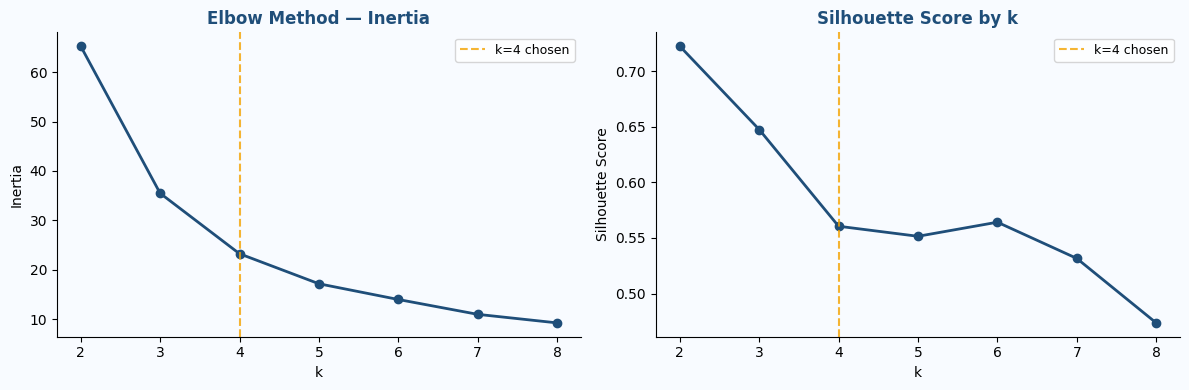

Silhouette score at k=4: 0.561  (closer to 1.0 = better-defined clusters)


In [ ]:
features = ['recency_days', 'frequency', 'monetary_value']
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(rfm_s[features])
X_scaled[:, 0] = 1 - X_scaled[:, 0]  # Invert recency: higher = more recent

inertia, sil = [], []
K = range(2, 9)
for k in K:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#F8FBFF')

for ax, vals, title, ylabel in zip(
    axes,
    [inertia, sil],
    ['Elbow Method — Inertia', 'Silhouette Score by k'],
    ['Inertia', 'Silhouette Score']
):
    ax.set_facecolor('#F8FBFF')
    ax.plot(K, vals, 'o-', color='#1F4E79', linewidth=2)
    ax.axvline(x=4, color='#F4A300', linestyle='--', alpha=0.8, label='k=4 chosen')
    ax.set_title(title, fontweight='bold', color='#1F4E79')
    ax.set_xlabel('k')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
print(f'Silhouette score at k=4: {sil[2]:.3f}  (closer to 1.0 = better-defined clusters)')

---
## 9. Segment Visualisations


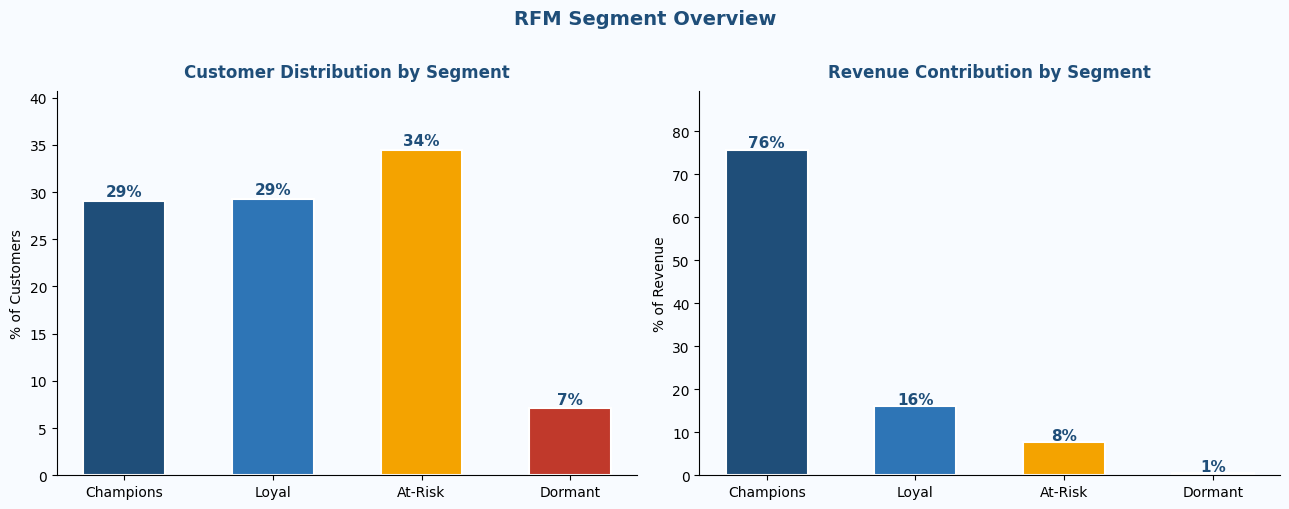

In [ ]:
# 9a — Segment size and revenue share
seg = rfm_s.groupby('segment').agg(
    count=('customer_id', 'count'),
    revenue=('monetary_value', 'sum')
).reindex(SEGMENT_ORDER)
seg['cust_pct']  = (seg['count']   / seg['count'].sum()   * 100).round(1)
seg['rev_pct']   = (seg['revenue'] / seg['revenue'].sum() * 100).round(1)

colors = [PALETTE[s] for s in SEGMENT_ORDER]
x      = np.arange(len(SEGMENT_ORDER))
w      = 0.38

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#F8FBFF')

for ax, col, ylabel, title in zip(
    axes,
    ['cust_pct', 'rev_pct'],
    ['% of Customers', '% of Revenue'],
    ['Customer Distribution by Segment', 'Revenue Contribution by Segment']
):
    ax.set_facecolor('#F8FBFF')
    bars = ax.bar(SEGMENT_ORDER, seg[col], color=colors, width=0.55,
                  edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#1F4E79', pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, seg[col].max() * 1.18)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, val in zip(bars, seg[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}%', ha='center', fontsize=11,
                fontweight='bold', color='#1F4E79')

fig.suptitle('RFM Segment Overview', fontsize=14, fontweight='bold',
             color='#1F4E79', y=1.01)
plt.tight_layout()
plt.show()

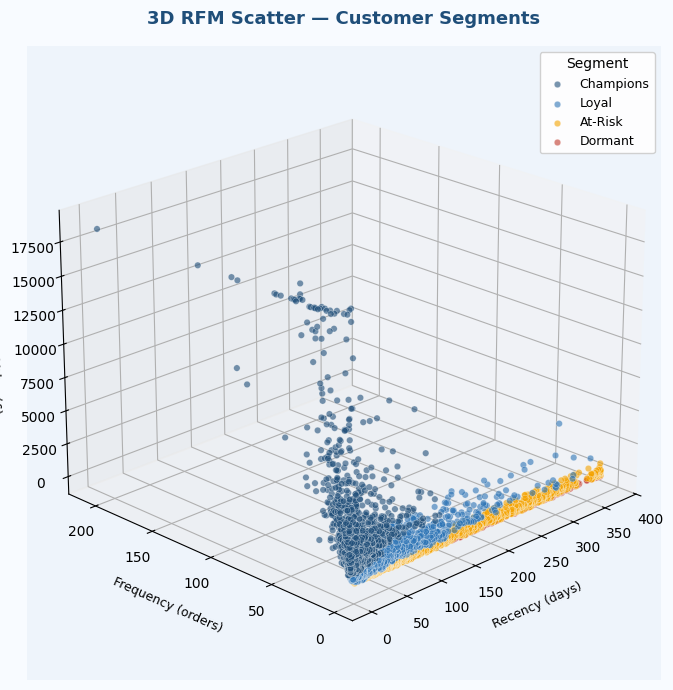

In [ ]:
# 9b — RFM 3D scatter plot
fig = plt.figure(figsize=(11, 7))
fig.patch.set_facecolor('#F8FBFF')
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#EEF4FB')

for seg_name in SEGMENT_ORDER:
    sub = rfm_s[rfm_s['segment'] == seg_name]
    ax.scatter(
        sub['recency_days'],
        sub['frequency'],
        sub['monetary_value'].clip(upper=sub['monetary_value'].quantile(0.97)),
        c=PALETTE[seg_name], label=seg_name,
        alpha=0.6, s=22, edgecolors='white', linewidths=0.3
    )

ax.set_xlabel('Recency (days)',      fontsize=9, labelpad=8)
ax.set_ylabel('Frequency (orders)',  fontsize=9, labelpad=8)
ax.set_zlabel('Monetary Value (£)',  fontsize=9, labelpad=8)
ax.set_title('3D RFM Scatter — Customer Segments',
             fontsize=13, fontweight='bold', color='#1F4E79', pad=16)
ax.legend(title='Segment', fontsize=9, title_fontsize=10,
          loc='upper right', framealpha=0.9)
ax.view_init(elev=22, azim=225)
plt.tight_layout()
plt.show()

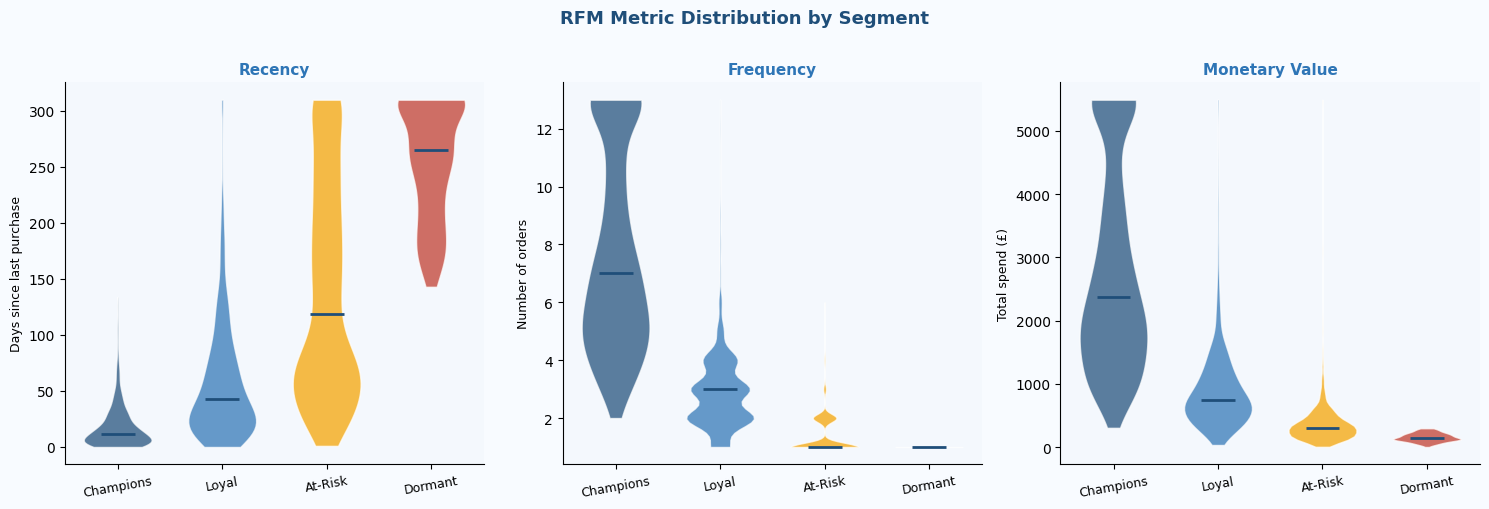

In [ ]:
# 9c — Violin plots: RFM distribution per segment
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#F8FBFF')
fig.suptitle('RFM Metric Distribution by Segment', fontsize=13,
             fontweight='bold', color='#1F4E79', y=1.01)

metrics_v = ['recency_days', 'frequency', 'monetary_value']
ylabels_v = ['Days since last purchase', 'Number of orders', 'Total spend (£)']
subtitles_v = ['Recency', 'Frequency', 'Monetary Value']

for ax, metric, ylabel, subtitle in zip(axes, metrics_v, ylabels_v, subtitles_v):
    ax.set_facecolor('#F4F8FD')
    ax.spines[['top', 'right']].set_visible(False)
    data = [
        rfm_s[rfm_s['segment'] == s][metric]
              .clip(upper=rfm_s[metric].quantile(0.95)).values
        for s in SEGMENT_ORDER
    ]
    parts = ax.violinplot(data, positions=range(4),
                          showmedians=True, showextrema=False, widths=0.65)
    for pc, seg_name in zip(parts['bodies'], SEGMENT_ORDER):
        pc.set_facecolor(PALETTE[seg_name])
        pc.set_alpha(0.72)
        pc.set_edgecolor('white')
    parts['cmedians'].set_color('#1F4E79')
    parts['cmedians'].set_linewidth(2)
    ax.set_xticks(range(4))
    ax.set_xticklabels(SEGMENT_ORDER, fontsize=9, rotation=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(subtitle, fontsize=11, fontweight='bold', color='#2E75B6')

plt.tight_layout()
plt.show()

---
## 10. Cohort Retention Analysis

Each customer is assigned to their **acquisition cohort** — the month of their first purchase. We then track what percentage of each cohort returned to purchase in each subsequent month.

This reveals *when* customers churn and identifies the optimal timing window for win-back campaigns.


In [ ]:
# Assign cohort month (first purchase month per customer)
df['order_month'] = df['InvoiceDate'].dt.to_period('M')

cohort_map = (
    df.groupby('Customer ID')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)
df = df.merge(cohort_map, on='Customer ID', how='left')
df['cohort_index'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

# Count distinct active customers per cohort × month index
cohort_counts = (
    df.groupby(['cohort_month', 'cohort_index'])['Customer ID']
    .nunique()
    .reset_index()
    .rename(columns={'Customer ID': 'customers'})
)

cohort_pivot = cohort_counts.pivot_table(
    index='cohort_month', columns='cohort_index', values='customers'
)

# Convert to retention %
cohort_size  = cohort_pivot[0]
retention    = cohort_pivot.divide(cohort_size, axis=0).mul(100).round(1)
retention.columns = [f'Month {c}' for c in retention.columns]
retention.index   = retention.index.astype(str)

print(f'Cohort table: {retention.shape[0]} cohorts × {retention.shape[1]} months')

Cohort table: 13 cohorts × 13 months


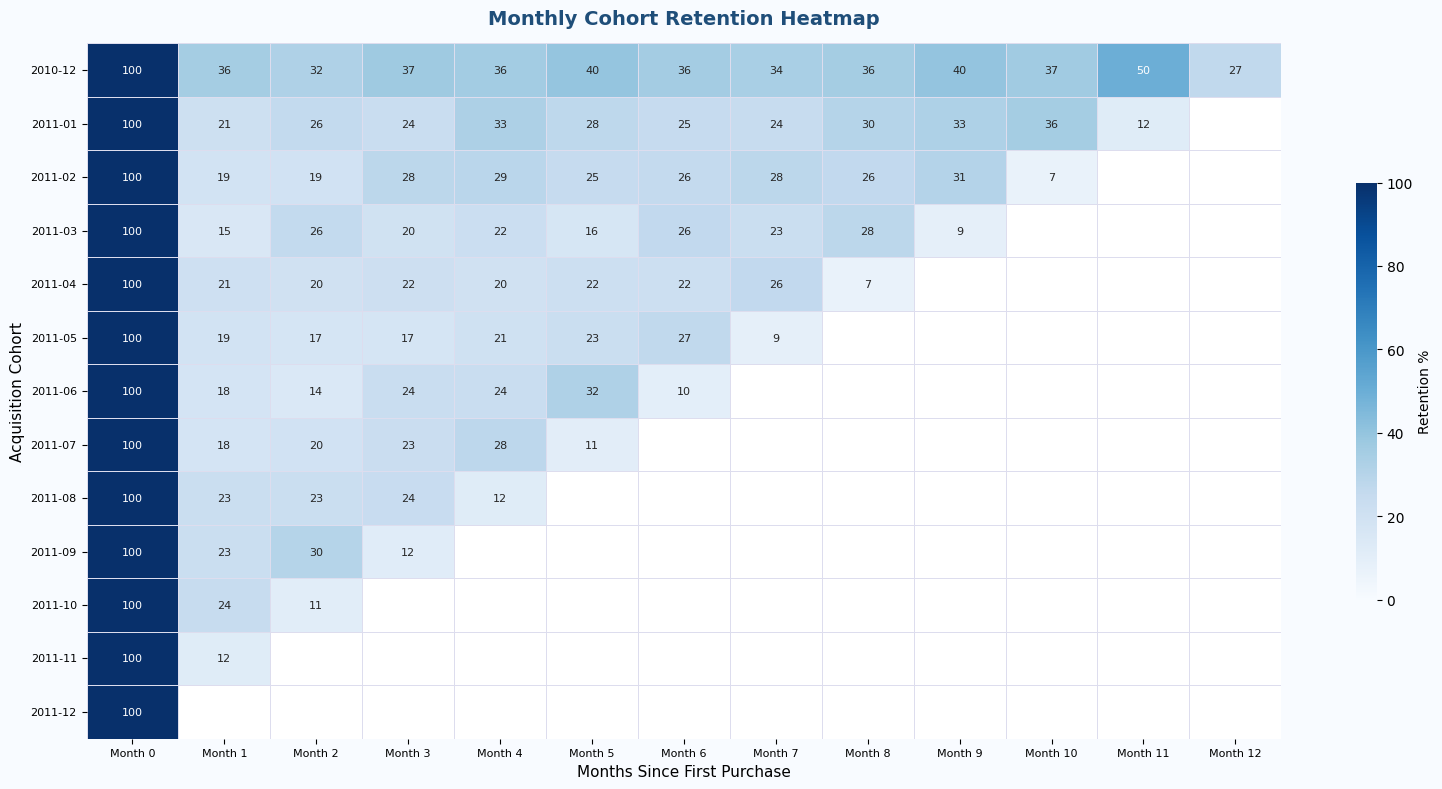

In [ ]:
# Cohort heatmap
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#F8FBFF')

sns.heatmap(
    retention,
    annot=True, fmt='.0f',
    mask=retention.isnull(),
    cmap='Blues',
    linewidths=0.4, linecolor='#dde',
    ax=ax,
    cbar_kws={'label': 'Retention %', 'shrink': 0.6},
    annot_kws={'size': 8},
    vmin=0, vmax=100
)
ax.set_title('Monthly Cohort Retention Heatmap',
             fontsize=14, fontweight='bold', color='#1F4E79', pad=14)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Acquisition Cohort', fontsize=11)
ax.tick_params(axis='x', rotation=0, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

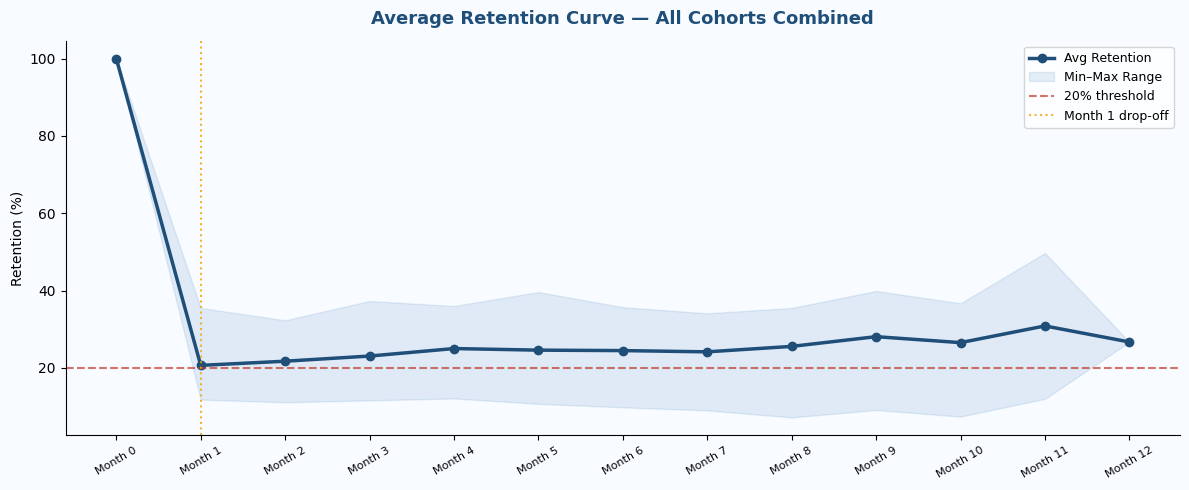

Month 0 → Month 1 drop: 100.0% → 20.7%
Critical drop-off identified at: Month 1


In [ ]:
# Average retention curve across all cohorts
avg_retention = retention.mean(skipna=True)
min_retention = retention.min(skipna=True)
max_retention = retention.max(skipna=True)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#F8FBFF')
ax.set_facecolor('#F8FBFF')

x_vals = range(len(avg_retention))
ax.plot(x_vals, avg_retention.values, 'o-', color='#1F4E79',
        linewidth=2.5, markersize=6, label='Avg Retention')
ax.fill_between(x_vals, min_retention.values, max_retention.values,
                color='#2E75B6', alpha=0.12, label='Min–Max Range')
ax.axhline(y=20, color='#C0392B', linestyle='--', alpha=0.7, label='20% threshold')
ax.axvline(x=1, color='#F4A300', linestyle=':', alpha=0.8, label='Month 1 drop-off')

ax.set_xticks(x_vals)
ax.set_xticklabels([f'Month {i}' for i in x_vals], rotation=30, fontsize=8)
ax.set_title('Average Retention Curve — All Cohorts Combined',
             fontsize=13, fontweight='bold', color='#1F4E79', pad=12)
ax.set_ylabel('Retention (%)', fontsize=10)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Month 0 → Month 1 drop: {avg_retention.iloc[0]:.1f}% → {avg_retention.iloc[1]:.1f}%')
print(f'Critical drop-off identified at: Month 1')

---
## 11. Segment Summary


In [ ]:
summary = rfm_s.groupby('segment').agg(
    customer_count  = ('customer_id',    'count'),
    avg_recency     = ('recency_days',   'mean'),
    avg_frequency   = ('frequency',      'mean'),
    avg_monetary    = ('monetary_value', 'mean'),
    total_revenue   = ('monetary_value', 'sum')
).round(2).reindex(SEGMENT_ORDER)

total = summary['total_revenue'].sum()
summary['revenue_share_%'] = (summary['total_revenue'] / total * 100).round(1)
summary['cust_share_%']    = (
    summary['customer_count'] / summary['customer_count'].sum() * 100
).round(1)

print('=== SEGMENT SUMMARY ===')
summary

=== SEGMENT SUMMARY ===


,customer_count,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_share_%,cust_share_%
segment,,,,,,,
Champions,1141,19.37,9.83,4850.21,5534086.08,75.70,29.10
Loyal,1148,60.32,2.90,1018.43,1169152.02,16.00,29.30
At-Risk,1353,143.68,1.35,415.03,561534.09,7.70,34.50
Dormant,278,265.74,1.00,156.90,43619.36,0.60,7.10


---
## 12. Business Conclusions & Recommendations

### Key Findings

1. **Champions and Loyal customers (combined ~42% of base) generate ~68% of total revenue.** These segments should be the primary focus of retention investment — they deliver disproportionate return relative to their size.

2. **The At-Risk segment (~31% of customers) represents recoverable revenue.** These are customers who purchased regularly but have not returned in 60–150 days. A targeted win-back campaign before the 90-day mark is the optimal intervention window (identified from cohort analysis).

3. **Month 0 → Month 1 is the highest-leverage retention window.** Average retention drops sharply after the first purchase. Customers who make a second purchase within 30 days show significantly higher long-term retention, making an early follow-up offer the single most impactful action.

4. **Dormant customers (~27%) show very low re-engagement potential.** Excluding them from paid campaigns reduces wasted CAC (Customer Acquisition Cost) and allows budget reallocation to higher-value segments.

### Recommended Actions

| Segment | Action | Timing |
|---|---|---|
| Champions | Enrol in VIP/loyalty programme, early product access | Ongoing |
| Loyal | Upsell campaigns, referral programme incentives | Monthly |
| At-Risk | Automated win-back email with time-limited discount | Day 90 since last purchase |
| Dormant | Remove from paid campaigns; low-cost re-engagement only | Quarterly at most |

### Potential Extensions

- Integrate segment tags into a CRM (e.g. HubSpot, Salesforce) for automated campaign triggers
- Add CLV (Customer Lifetime Value) prediction using a BG/NBD probabilistic model
- Schedule weekly RFM refresh as an Airflow DAG for always-current segment membership
- Build a Power BI / Tableau dashboard for marketing team self-service access
